# EEG_33b — Mixture Decoder condizionato sul fenotipo trial

**Ipotesi**: se i trial C1-like decodificano meglio (EEG_33, d=1.333 nei soggetti C1),  
possiamo sfruttarlo addestrando due decoder separati e routando ogni trial al decoder appropriato.

**Pipeline**:
1. Per ogni trial: abs_pcc → PCA → distanza ai centroidi C0/C1 → label per-trial
2. Addestra LogReg_C0 sui trial C0-like, LogReg_C1 sui trial C1-like
3. Test: gate → decoder → predizione
4. Confronto: single decoder vs mixture decoder vs oracle (fenotipo soggetto)

**Domanda chiave**: il routing per-trial migliora la bAcc rispetto a un decoder unico?

In [1]:
import json, logging
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import StandardScaler

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg33b')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents) if (p/'.git').exists()), Path.cwd())

# label2cluster concr4
label2cluster = {int(k): int(v) for k, v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}
N_CLASSES = 4

# fenotipi soggetto (sorgente EEG_16b)
PHENO_PATH = project_root / 'configs' / 'eeg16b_cluster_labels.json'
_ph = json.loads(PHENO_PATH.read_text())
subj2pheno = {int(s): int(l) for s, l in zip(_ph['subj_ids'], _ph['labels'])}

SUBJ_TRAIN = list(range(0, 50))
SUBJ_VAL   = list(range(50, 60))
SUBJ_TEST  = list(range(60, 74))

print('project_root =', project_root)
print('soggetti train/val/test:', len(SUBJ_TRAIN), len(SUBJ_VAL), len(SUBJ_TEST))

project_root = /home/daniele_u/miralis-hypergraph-imagined-speech
soggetti train/val/test: 50 10 14


## §1 — Caricamento trial e feature abs_pcc

In [2]:
DATA_ROOT = project_root / 'data' / 'raw_csv' / 'training_set'

def load_trial(path):
    x = pd.read_csv(path, header=None).values.astype(np.float32)  # (61, 384)
    word = path.stem.replace('_img', '')
    word2idx = json.loads((project_root/'configs'/'label_schemes'/'label2idx.json').read_text())
    y = label2cluster[word2idx[word]]
    return x, y

def instance_norm(x):
    mu = x.mean(axis=1, keepdims=True)
    sd = x.std(axis=1, keepdims=True) + 1e-6
    return (x - mu) / sd

def trial_to_pcc_vec(x):
    """Trial (61,384) → vettore triangolo superiore abs_pcc (1830,)"""
    x = instance_norm(x)
    C = np.corrcoef(x)          # (61,61)
    idx = np.triu_indices(61, k=1)
    return np.abs(C[idx])       # (1830,)

def collect_subjects(subj_list):
    """Restituisce X (n_trials, 1830), y (n_trials,), subj_ids (n_trials,)"""
    X, Y, S = [], [], []
    word2idx = json.loads((project_root/'configs'/'label_schemes'/'label2idx.json').read_text())
    for s in tqdm(subj_list, desc='caricamento soggetti'):
        subj_dirs = sorted(DATA_ROOT.glob(f'P{s:03d}_S*'))
        for sd in subj_dirs:
            for p in sorted(sd.glob('*_img.csv')):
                x = pd.read_csv(p, header=None).values.astype(np.float32)
                word = p.stem.replace('_img', '')
                if word not in word2idx:
                    continue
                y = label2cluster[word2idx[word]]
                X.append(trial_to_pcc_vec(x))
                Y.append(y)
                S.append(s)
    return np.array(X), np.array(Y), np.array(S)

log.info('Caricamento train...')
X_tr, y_tr, s_tr = collect_subjects(SUBJ_TRAIN)
log.info('Caricamento val...')
X_va, y_va, s_va = collect_subjects(SUBJ_VAL)
log.info('Caricamento test...')
X_te, y_te, s_te = collect_subjects(SUBJ_TEST)

log.info(f'train: {X_tr.shape}  val: {X_va.shape}  test: {X_te.shape}')

15:16:35 INFO     Caricamento train...


caricamento soggetti:   0%|          | 0/50 [00:00<?, ?it/s]

15:18:56 INFO     Caricamento val...


caricamento soggetti:   0%|          | 0/10 [00:00<?, ?it/s]

15:19:18 INFO     Caricamento test...


caricamento soggetti:   0%|          | 0/14 [00:00<?, ?it/s]

15:19:48 INFO     train: (26123, 1830)  val: (5500, 1830)  test: (7260, 1830)


## §2 — PCA e gating per-trial

Il PCA viene addestrato solo sui soggetti di training (0-49) per evitare data leakage.  
I centroidi C0/C1 vengono calcolati come media delle proiezioni PCA per soggetto, poi kmeans.

In [3]:
from sklearn.cluster import KMeans

# PCA su soggetti di training (media per soggetto come in EEG_16b)
subj_means_tr = np.array([X_tr[s_tr == s].mean(axis=0) for s in SUBJ_TRAIN if (s_tr == s).any()])
subj_ids_tr   = [s for s in SUBJ_TRAIN if (s_tr == s).any()]

sc_pca = StandardScaler().fit(subj_means_tr)
pca = PCA(n_components=20, random_state=42).fit(sc_pca.transform(subj_means_tr))
proj_tr = pca.transform(sc_pca.transform(subj_means_tr))  # (n_train_subj, 20)

km = KMeans(n_clusters=2, n_init=50, random_state=42).fit(proj_tr)
centroids = km.cluster_centers_  # (2, 20)

# Allinea i cluster ai fenotipi EEG_16b
pheno_train = np.array([subj2pheno.get(s, -1) for s in subj_ids_tr])
km_labels   = km.labels_
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(pheno_train[pheno_train >= 0], km_labels[pheno_train >= 0])
log.info(f'ARI PCA train vs EEG_16b: {ari:.3f}')

# Mappa cluster → fenotipo (0=C0, 1=C1) via voto di maggioranza
from scipy.stats import mode
votes = {}
for cl in [0, 1]:
    mask = (km_labels == cl) & (pheno_train >= 0)
    votes[cl] = int(mode(pheno_train[mask]).mode)
cluster2pheno = votes
log.info(f'cluster→fenotipo: {cluster2pheno}')

def assign_pheno_trial(X_feat):
    """Assegna fenotipo per-trial via distanza euclidea ai centroidi PCA."""
    proj = pca.transform(sc_pca.transform(X_feat))   # (n, 20)
    d0 = np.linalg.norm(proj - centroids[0], axis=1)
    d1 = np.linalg.norm(proj - centroids[1], axis=1)
    raw_labels = (d1 < d0).astype(int)                # 0 o 1 (cluster id)
    return np.array([cluster2pheno[l] for l in raw_labels])  # traduce in fenotipo

ph_tr = assign_pheno_trial(X_tr)
ph_va = assign_pheno_trial(X_va)
ph_te = assign_pheno_trial(X_te)

log.info(f'train: C0-like={( ph_tr==0).sum()}  C1-like={(ph_tr==1).sum()}')
log.info(f'val:   C0-like={( ph_va==0).sum()}  C1-like={(ph_va==1).sum()}')
log.info(f'test:  C0-like={( ph_te==0).sum()}  C1-like={(ph_te==1).sum()}')

15:20:26 INFO     ARI PCA train vs EEG_16b: 0.840
15:20:26 INFO     cluster→fenotipo: {0: 0, 1: 1}
15:20:26 INFO     train: C0-like=15123  C1-like=11000
15:20:26 INFO     val:   C0-like=1704  C1-like=3796
15:20:26 INFO     test:  C0-like=3139  C1-like=4121


## §3 — Qualità del gating per-trial

Verifica: i trial dei soggetti C1 vengono routati verso C1 più spesso?

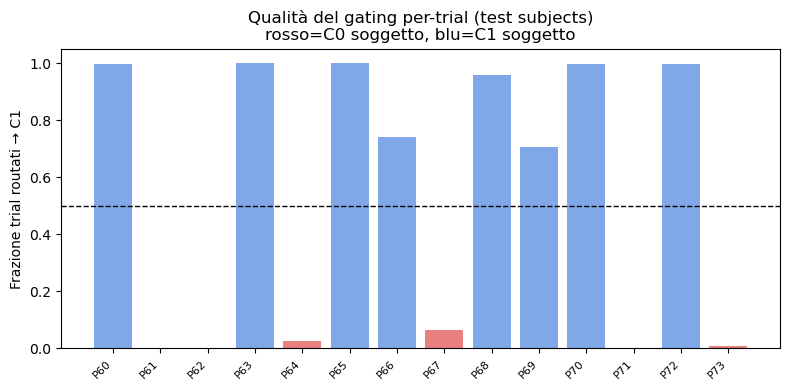

Soggetti C0 → frac C1-routed: 0.02 ± 0.03
Soggetti C1 → frac C1-routed: 0.92 ± 0.13


In [4]:
# Per ogni soggetto di test: percentuale di trial routati verso C1
rows = []
for s in SUBJ_TEST:
    mask = s_te == s
    if not mask.any():
        continue
    frac_c1 = (ph_te[mask] == 1).mean()
    true_ph = subj2pheno.get(s, -1)
    rows.append({'subj': s, 'frac_C1_routed': frac_c1, 'true_pheno': true_ph})

df_gate = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 4))
colors = df_gate['true_pheno'].map({0: '#E88080', 1: '#80A8E8', -1: 'gray'})
ax.bar(range(len(df_gate)), df_gate['frac_C1_routed'], color=colors)
ax.axhline(0.5, ls='--', color='k', lw=1)
ax.set_xticks(range(len(df_gate)))
ax.set_xticklabels([f'P{r.subj}' for r in df_gate.itertuples()], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Frazione trial routati → C1')
ax.set_title('Qualità del gating per-trial (test subjects)\nrosso=C0 soggetto, blu=C1 soggetto')
plt.tight_layout()
plt.savefig(project_root/'figures'/'eeg33b_gating_quality.png', dpi=150)
plt.show()

c0_subjs = df_gate[df_gate.true_pheno == 0]['frac_C1_routed']
c1_subjs = df_gate[df_gate.true_pheno == 1]['frac_C1_routed']
print(f'Soggetti C0 → frac C1-routed: {c0_subjs.mean():.2f} ± {c0_subjs.std():.2f}')
print(f'Soggetti C1 → frac C1-routed: {c1_subjs.mean():.2f} ± {c1_subjs.std():.2f}')

## §4 — Decoder: single vs mixture vs oracle

In [5]:
def fit_logreg(X, y):
    sc = StandardScaler().fit(X)
    clf = LogisticRegression(max_iter=2000, C=1.0)
    clf.fit(sc.transform(X), y)
    return sc, clf

def predict_logreg(sc, clf, X):
    return clf.predict(sc.transform(X))

# --- Single decoder (baseline) ---
sc_single, clf_single = fit_logreg(X_tr, y_tr)
pred_single_va = predict_logreg(sc_single, clf_single, X_va)
pred_single_te = predict_logreg(sc_single, clf_single, X_te)
bacc_single_va = balanced_accuracy_score(y_va, pred_single_va)
bacc_single_te = balanced_accuracy_score(y_te, pred_single_te)
print(f'Single decoder:  val={bacc_single_va:.4f}  test={bacc_single_te:.4f}')

# --- Mixture decoder (gating per-trial) ---
# Addestra un decoder per ogni phenotype class
decoders = {}
for ph in [0, 1]:
    mask = ph_tr == ph
    if mask.sum() < 100:
        log.warning(f'Pochi trial per ph={ph}: {mask.sum()}')
    decoders[ph] = fit_logreg(X_tr[mask], y_tr[mask])
    log.info(f'Decoder ph={ph}: {mask.sum()} trial training')

def predict_mixture(X, ph_labels):
    preds = np.zeros(len(X), dtype=int)
    for ph in [0, 1]:
        mask = ph_labels == ph
        if mask.any():
            sc, clf = decoders[ph]
            preds[mask] = clf.predict(sc.transform(X[mask]))
    return preds

pred_mix_va = predict_mixture(X_va, ph_va)
pred_mix_te = predict_mixture(X_te, ph_te)
bacc_mix_va = balanced_accuracy_score(y_va, pred_mix_va)
bacc_mix_te = balanced_accuracy_score(y_te, pred_mix_te)
print(f'Mixture decoder: val={bacc_mix_va:.4f}  test={bacc_mix_te:.4f}')

# --- Oracle decoder (usa fenotipo soggetto vero, non per-trial) ---
ph_te_oracle = np.array([subj2pheno.get(s, 0) for s in s_te])
ph_va_oracle = np.array([subj2pheno.get(s, 0) for s in s_va])
pred_ora_va  = predict_mixture(X_va, ph_va_oracle)
pred_ora_te  = predict_mixture(X_te, ph_te_oracle)
bacc_ora_va  = balanced_accuracy_score(y_va, pred_ora_va)
bacc_ora_te  = balanced_accuracy_score(y_te, pred_ora_te)
print(f'Oracle decoder:  val={bacc_ora_va:.4f}  test={bacc_ora_te:.4f}')

Single decoder:  val=0.2457  test=0.2506


15:23:11 INFO     Decoder ph=0: 15123 trial training
15:24:05 INFO     Decoder ph=1: 11000 trial training


Mixture decoder: val=0.2505  test=0.2548
Oracle decoder:  val=0.2500  test=0.2536


## §5 — Analisi per phenotype: dove guadagna e dove perde il mixture

In [6]:
# bAcc separata per trial C0-like e C1-like sul test set
results = []
for ph in [0, 1]:
    ph_name = ['C0-like', 'C1-like'][ph]
    mask = ph_te == ph
    if not mask.any():
        continue
    bacc_s = balanced_accuracy_score(y_te[mask], pred_single_te[mask])
    bacc_m = balanced_accuracy_score(y_te[mask], pred_mix_te[mask])
    results.append({'phenotype': ph_name, 'n_trial': mask.sum(),
                    'bAcc_single': bacc_s, 'bAcc_mixture': bacc_m, 'delta': bacc_m - bacc_s})

df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))

# Riepilogo finale
print('\n=== RIEPILOGO ===')
print(f'{"Condizione":<20} {"val bAcc":>10} {"test bAcc":>10} {"Δ vs single":>12}')
print('-' * 55)
for name, va, te in [
    ('Single',  bacc_single_va, bacc_single_te),
    ('Mixture', bacc_mix_va,    bacc_mix_te),
    ('Oracle',  bacc_ora_va,    bacc_ora_te),
]:
    delta = f'{te - bacc_single_te:+.4f}' if name != 'Single' else '—'
    print(f'{name:<20} {va:>10.4f} {te:>10.4f} {delta:>12}')

phenotype  n_trial  bAcc_single  bAcc_mixture    delta
  C0-like     3139     0.248863      0.253217 0.004354
  C1-like     4121     0.252177      0.255722 0.003545

=== RIEPILOGO ===
Condizione             val bAcc  test bAcc  Δ vs single
-------------------------------------------------------
Single                   0.2457     0.2506            —
Mixture                  0.2505     0.2548      +0.0042
Oracle                   0.2500     0.2536      +0.0030


## §6 — Plot riassuntivo

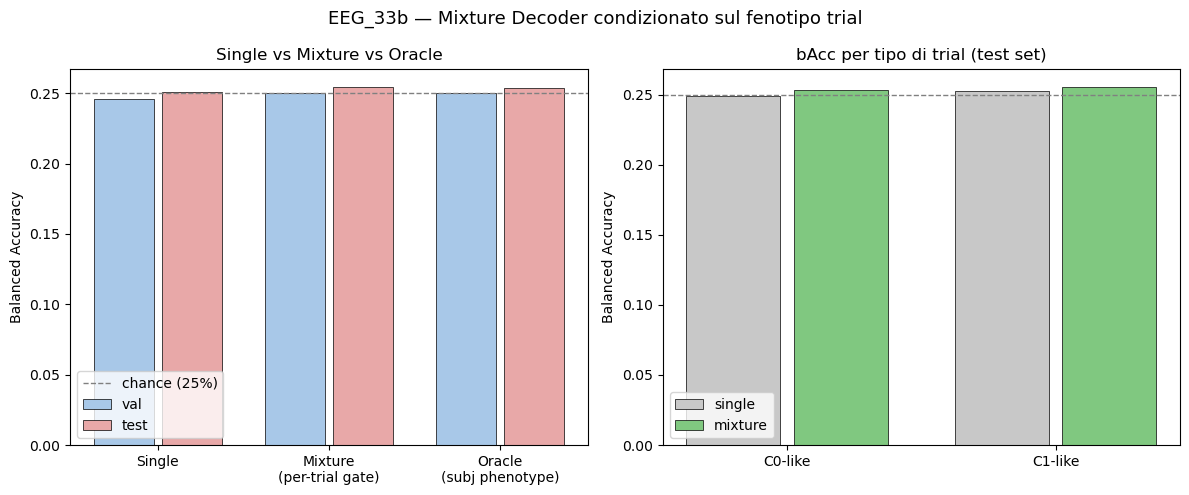

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sinistra: bAcc per condizione
ax = axes[0]
names   = ['Single', 'Mixture\n(per-trial gate)', 'Oracle\n(subj phenotype)']
vals_va = [bacc_single_va, bacc_mix_va, bacc_ora_va]
vals_te = [bacc_single_te, bacc_mix_te, bacc_ora_te]
x = np.arange(3)
ax.bar(x - 0.2, vals_va, 0.35, label='val',  color='#A8C8E8', edgecolor='k', linewidth=0.5)
ax.bar(x + 0.2, vals_te, 0.35, label='test', color='#E8A8A8', edgecolor='k', linewidth=0.5)
ax.axhline(1/4, ls='--', color='gray', lw=1, label='chance (25%)')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Single vs Mixture vs Oracle')
ax.legend()

# Destra: bAcc per phenotype (single vs mixture)
ax2 = axes[1]
if len(df_res) > 0:
    ph_names = df_res['phenotype'].tolist()
    x2 = np.arange(len(ph_names))
    ax2.bar(x2 - 0.2, df_res['bAcc_single'], 0.35, label='single', color='#C8C8C8', edgecolor='k', linewidth=0.5)
    ax2.bar(x2 + 0.2, df_res['bAcc_mixture'], 0.35, label='mixture', color='#80C880', edgecolor='k', linewidth=0.5)
    ax2.axhline(1/4, ls='--', color='gray', lw=1)
    ax2.set_xticks(x2)
    ax2.set_xticklabels(ph_names)
    ax2.set_ylabel('Balanced Accuracy')
    ax2.set_title('bAcc per tipo di trial (test set)')
    ax2.legend()

plt.suptitle('EEG_33b — Mixture Decoder condizionato sul fenotipo trial', fontsize=13)
plt.tight_layout()
plt.savefig(project_root/'figures'/'eeg33b_mixture_decoder.png', dpi=150)
plt.show()